# **CODSOFT INTERNSHIP TASK 4**

# SALES PREDICTION USING PYTHON

# *Importing the needed Libraries*

In [2]:
# Import the numpy and pandas package
import numpy as np
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
ad_data = pd.read_csv("advertising.csv")
ad_data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
ad_data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
ad_data.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [6]:
ad_data.shape

(200, 4)

In [7]:
ad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
# Checking Null values
ad_data.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

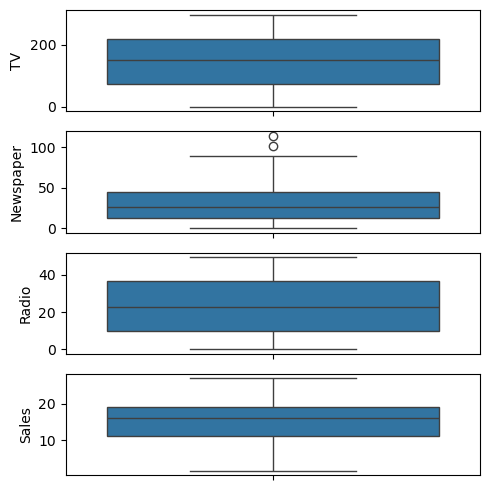

In [14]:
# Outlier Analysis
fig, axs = plt.subplots(4, figsize = (5,5))
plt1 = sns.boxplot(ad_data['TV'], ax = axs[0])
plt2 = sns.boxplot(ad_data['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(ad_data['Radio'], ax = axs[2])
plt4 = sns.boxplot(ad_data['Sales'], ax = axs[3])
plt.tight_layout()

# Exploratory Data Analysis

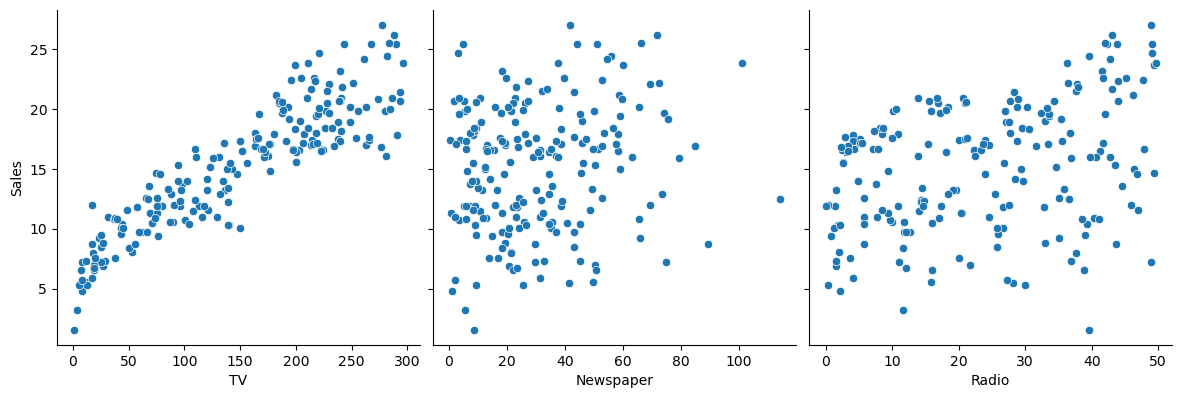

In [15]:
# Trying to check how Sales are related with other variables using scatter plot.
sns.pairplot(ad_data, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

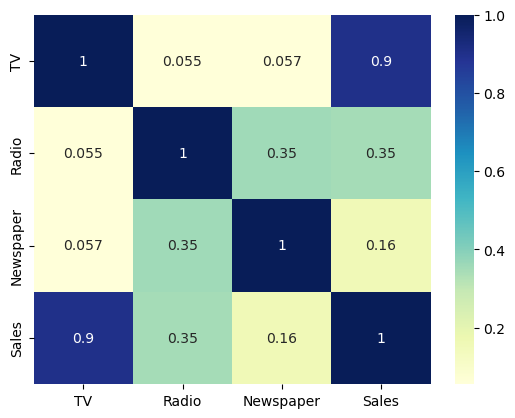

In [25]:
# Let's see the correlation between different variables.
sns.heatmap(ad_data.corr(), cmap="YlGnBu", annot = True)
plt.show()

In [26]:
X = ad_data['TV']
y = ad_data['Sales']

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [30]:
# Let's now take a look at the train dataset

X_train.head()

169    284.3
97     184.9
31     112.9
12      23.8
35     290.7
Name: TV, dtype: float64

In [31]:
y_train.head()

169    20.0
97     20.5
31     11.9
12      9.2
35     17.8
Name: Sales, dtype: float64

In [33]:
# Building Linear Model
import statsmodels.api as sm

In [34]:
# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the resgression line using 'OLS'
lr = sm.OLS(y_train, X_train_sm).fit()

In [35]:
# Print the parameters, i.e. the intercept and the slope of the regression line fitted
lr.params

const    7.206555
TV       0.054835
dtype: float64

In [36]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     550.7
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           5.08e-50
Time:                        07:41:27   Log-Likelihood:                -314.94
No. Observations:                 140   AIC:                             633.9
Df Residuals:                     138   BIC:                             639.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2066      0.414     17.392      0.000       6.387       8.026
TV             0.0548      0.002     23.467      0.000       0.050       0.059
==============================================================================
Omnibus:                        1.138   Durbin-Watson:                   2.351
Prob(Omnibus):                  0.566   Jarque-Bera (JB):                1.240
Skew:                          -0.190   Prob(JB):                        0.538
Kurtosis:                       2.739   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Looking at the summary above

1. coefficients and significance (p-values)
2. R-squared
3. F statistic and its significance as well


1. The coefficent for TV is 54% which is very low in value
2. R - squared has 80% meaning the variance in sales is explained by TV
3. F statistics has low value

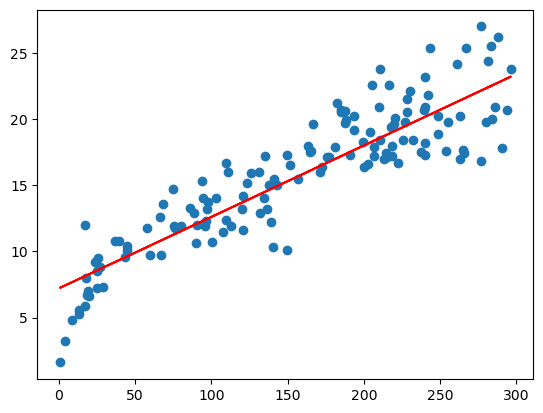

In [38]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 7.206 + 0.054*X_train, 'r')
plt.show()

# Model Evaluation 

In [39]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

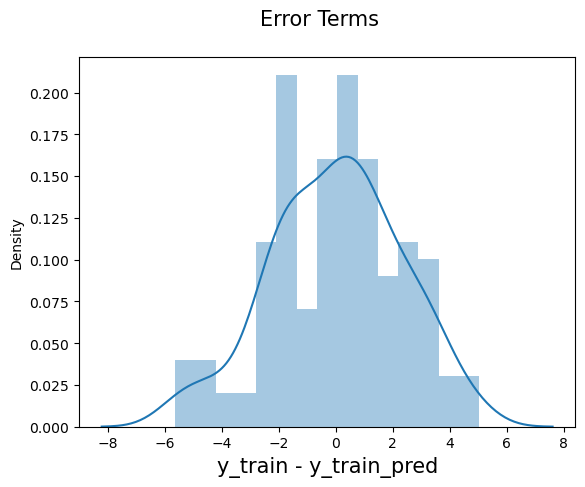

In [40]:
fig = plt.figure()
sns.distplot(res, bins = 15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading 
plt.xlabel('y_train - y_train_pred', fontsize = 15)         # X-label
plt.show()

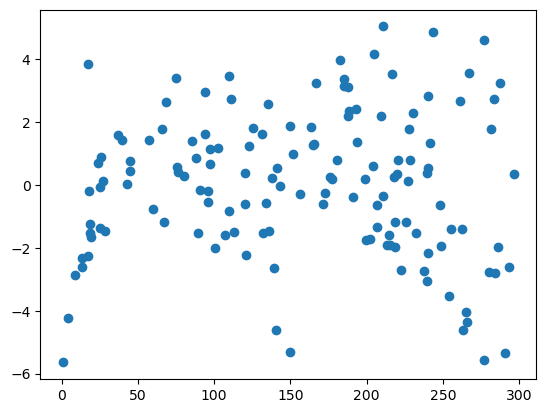

In [41]:
plt.scatter(X_train,res)
plt.show()

* Predictions on the Testset

* After fiting the regression line on the trained dataset, now we are making some predictions on the test data.


In [42]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_sm
y_pred = lr.predict(X_test_sm)

In [43]:
y_pred.head()

95     16.161091
15     17.921291
30     23.267692
158     7.848123
128    19.286679
dtype: float64

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [45]:
#Returns the mean squared error; we'll take a square root
np.sqrt(mean_squared_error(y_test, y_pred))

2.27585706980176

In [46]:
r_squared = r2_score(y_test, y_pred)
r_squared

0.814855389208679